# Macroeconomic Data Analysis: TASI and MOEX

## Project Overview

This project analyzes the relationship between selected macroeconomic variables and stock market indices in Saudi Arabia and Russia using quarterly data from 2015 Q1 to 2023 Q4.

The analysis focuses on two stock market indices:

- **TASI** — Saudi Arabia
- **MOEX** — Russia

The explanatory variables include:

- Oil Price
- Interest Rate
- Inflation
- Exchange Rate

## Objectives

The analysis aims to:

1. Explore the characteristics and relationships within the dataset.
2. Examine correlations between macroeconomic variables and stock market indices.
3. Estimate multiple linear regression models for TASI and MOEX.
4. Evaluate model fit and statistical significance.
5. Check for potential multicollinearity using Variance Inflation Factors (VIF).

## Tools & Libraries

- Python
- pandas
- statsmodels
- matplotlib
- seaborn

## Analysis Period

**2015 Q1 – 2023 Q4**

## 1. Dataset Preparation

In [1]:
# Macroeconomic Data Analysis
# TASI & MOEX | Quarterly Data, 2015–2023

import pandas as pd
import statsmodels.api as sm
import seaborn as sns
import matplotlib.pyplot as plt

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Create the quarterly dataset

data = {
    'Oil_Price': [68.35, 68.52, 71.26, 63.71, 53.68, 60.80, 62.15, 59.72,
                  59.72, 63.28, 69.12, 60.15, 54.74, 68.69, 58.68, 64.59,
                  61.35, 63.50, 68.74, 68.33, 59.10, 68.24, 69.31, 69.18,
                  61.36, 67.03, 57.95, 69.39, 63.68, 66.04, 66.21, 57.72,
                  66.87, 58.10, 60.65, 73.22],

    'Interest_SA': [2.38, 2.67, 2.50, 2.55, 2.59, 2.59, 2.40, 2.37,
                    2.40, 2.53, 2.49, 2.49, 2.49, 2.47, 2.49, 2.49,
                    2.58, 2.53, 2.59, 2.71, 2.37, 2.46, 2.57, 2.76,
                    2.41, 2.56, 2.47, 2.43, 2.44, 2.48, 2.45, 2.68,
                    2.38, 2.83, 2.68, 2.57],

    'Interest_RU': [6.30, 6.57, 6.31, 6.51, 6.40, 6.45, 6.60, 6.55,
                    6.45, 6.41, 6.58, 6.51, 6.72, 6.51, 6.54, 5.92,
                    6.52, 6.27, 6.66, 6.43, 6.46, 6.55, 6.83, 6.30,
                    6.43, 6.47, 6.58, 6.73, 6.41, 6.59, 6.66, 6.59,
                    6.89, 6.55, 6.54, 6.75],

    'Inflation_SA': [2.40, 2.21, 1.54, 2.00, 2.19, 1.78, 2.08, 2.03,
                     2.00, 1.95, 2.13, 2.36, 1.71, 2.31, 2.07, 2.13,
                     1.66, 2.04, 2.45, 1.68, 1.41, 1.48, 2.08, 2.72,
                     2.34, 2.50, 2.03, 2.42, 1.92, 2.18, 1.92, 1.84,
                     2.04, 1.86, 2.39, 2.06],

    'Inflation_RU': [4.78, 4.26, 5.38, 3.99, 4.96, 4.25, 3.84, 4.16,
                     3.94, 4.35, 4.26, 4.72, 4.90, 4.40, 4.48, 4.70,
                     4.12, 5.00, 5.09, 4.64, 6.18, 5.14, 4.42, 4.25,
                     4.34, 4.15, 5.29, 4.01, 4.44, 4.13, 5.23, 3.51,
                     4.25, 4.41, 4.72, 4.82],

    'USD_SAR': [3.75, 3.77, 3.76, 3.80, 3.72, 3.76, 3.73, 3.73,
                3.79, 3.78, 3.71, 3.75, 3.75, 3.71, 3.75, 3.76,
                3.75, 3.71, 3.77, 3.75, 3.75, 3.73, 3.76, 3.77,
                3.74, 3.75, 3.77, 3.71, 3.75, 3.71, 3.73, 3.76,
                3.75, 3.74, 3.74, 3.77],

    'USD_RUB': [73.53, 66.06, 71.46, 67.65, 82.02, 66.30, 68.44, 68.26,
                67.80, 70.71, 71.37, 61.91, 67.13, 63.40, 76.18, 82.33,
                76.92, 71.73, 75.11, 70.83, 78.28, 73.34, 68.85, 64.35,
                66.80, 71.57, 63.87, 68.89, 76.70, 70.15, 79.93, 77.24,
                68.56, 63.20, 69.76, 67.60],

    'TASI': [6845.58, 7203.26, 7299.53, 7340.84, 7329.57, 7290.20,
             7325.95, 7163.13, 6926.41, 7335.90, 7348.76, 7334.39,
             7583.54, 7848.52, 7972.66, 7984.45, 8546.74, 8881.32,
             9238.92, 8875.95, 8725.43, 9204.75, 9133.00, 9484.78,
             9459.52, 9602.02, 9535.35, 9562.23, 9689.68, 9618.34,
             9811.96, 10158.31, 10786.22, 11217.80, 11453.72, 11199.77],

    'MOEX': [160.10, 184.00, 168.61, 161.08, 150.73, 143.55, 141.73,
             141.71, 129.34, 127.93, 133.27, 142.15, 143.68, 115.86,
             141.14, 176.02, 185.24, 168.10, 152.55, 178.38, 192.83,
             202.46, 187.34, 205.05, 196.92, 184.76, 185.45, 177.79,
             184.23, 184.33, 181.52, 154.09, 152.18, 136.83, 123.97,
             123.83]
}

df = pd.DataFrame(data)

print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (36, 9)


,Oil_Price,Interest_SA,Interest_RU,Inflation_SA,Inflation_RU,USD_SAR,USD_RUB,TASI,MOEX
0,68.35,2.38,6.30,2.40,4.78,3.75,73.53,6845.58,160.10
1,68.52,2.67,6.57,2.21,4.26,3.77,66.06,7203.26,184.00
2,71.26,2.50,6.31,1.54,5.38,3.76,71.46,7299.53,168.61
3,63.71,2.55,6.51,2.00,3.99,3.80,67.65,7340.84,161.08
4,53.68,2.59,6.40,2.19,4.96,3.72,82.02,7329.57,150.73


In [3]:
# Add quarterly time labels

df.insert(
    0,
    'Quarter',
    pd.period_range(start='2015Q1', periods=len(df), freq='Q')
)

df.head()

,Quarter,Oil_Price,Interest_SA,Interest_RU,Inflation_SA,Inflation_RU,USD_SAR,USD_RUB,TASI,MOEX
0,2015Q1,68.35,2.38,6.30,2.40,4.78,3.75,73.53,6845.58,160.10
1,2015Q2,68.52,2.67,6.57,2.21,4.26,3.77,66.06,7203.26,184.00
2,2015Q3,71.26,2.50,6.31,1.54,5.38,3.76,71.46,7299.53,168.61
3,2015Q4,63.71,2.55,6.51,2.00,3.99,3.80,67.65,7340.84,161.08
4,2016Q1,53.68,2.59,6.40,2.19,4.96,3.72,82.02,7329.57,150.73


## 2. Data Quality Check

In [4]:
# Check dataset quality

print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nData types:")
print(df.dtypes)

Missing values:
Quarter         0
Oil_Price       0
Interest_SA     0
Interest_RU     0
Inflation_SA    0
Inflation_RU    0
USD_SAR         0
USD_RUB         0
TASI            0
MOEX            0
dtype: int64

Duplicate rows:
0

Data types:
Quarter         period[Q-DEC]
Oil_Price             float64
Interest_SA           float64
Interest_RU           float64
Inflation_SA          float64
Inflation_RU          float64
USD_SAR               float64
USD_RUB               float64
TASI                  float64
MOEX                  float64
dtype: object


## 3. Descriptive Statistics

In [5]:
# Descriptive statistics

df.describe().T

,count,mean,std,min,25%,50%,75%,max
Oil_Price,36.0,63.975833,4.904952,53.68,60.0425,63.695,68.3925,73.22
Interest_SA,36.0,2.523611,0.113217,2.37,2.4475,2.490,2.5825,2.83
Interest_RU,36.0,6.515000,0.175018,5.92,6.4300,6.530,6.5900,6.89
Inflation_SA,36.0,2.053056,0.298241,1.41,1.9050,2.050,2.2350,2.72
Inflation_RU,36.0,4.541944,0.521951,3.51,4.2275,4.415,4.8400,6.18
USD_SAR,36.0,3.748056,0.022781,3.71,3.7300,3.750,3.7600,3.80
USD_RUB,36.0,70.784167,5.302398,61.91,67.4825,69.955,73.9250,82.33
TASI,36.0,8675.513889,1344.503265,6845.58,7335.5225,8800.690,9572.1775,11453.72
MOEX,36.0,161.631944,25.062446,115.86,141.7250,160.590,184.2550,205.05


## 4. Regression Analysis

### 4.1 TASI Regression Model

In [6]:
# Multiple Linear Regression: TASI

X_tasi = df[['Oil_Price', 'Interest_SA', 'Inflation_SA', 'USD_SAR']]
y_tasi = df['TASI']

X_tasi = sm.add_constant(X_tasi)

model_tasi = sm.OLS(y_tasi, X_tasi).fit()

print("=== Regression Model: TASI ===")
print(model_tasi.summary())


=== Regression Model: TASI ===
                            OLS Regression Results                            
Dep. Variable:                   TASI   R-squared:                       0.165
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     1.533
Date:                Wed, 07 Oct 2026   Prob (F-statistic):              0.217
Time:                        19:00:41   Log-Likelihood:                -306.66
No. Observations:                  36   AIC:                             623.3
Df Residuals:                      31   BIC:                             631.2
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         3.6

### 4.2 MOEX Regression Model

In [7]:
# Multiple Linear Regression: MOEX

X_moex = df[['Oil_Price', 'Interest_RU', 'Inflation_RU', 'USD_RUB']]
y_moex = df['MOEX']

X_moex = sm.add_constant(X_moex)

model_moex = sm.OLS(y_moex, X_moex).fit()

print("=== Regression Model: MOEX ===")
print(model_moex.summary())


=== Regression Model: MOEX ===
                            OLS Regression Results                            
Dep. Variable:                   MOEX   R-squared:                       0.141
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     1.277
Date:                Wed, 07 Oct 2026   Prob (F-statistic):              0.300
Time:                        19:03:25   Log-Likelihood:                -163.80
No. Observations:                  36   AIC:                             337.6
Df Residuals:                      31   BIC:                             345.5
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           9

## 5. Correlation Analysis

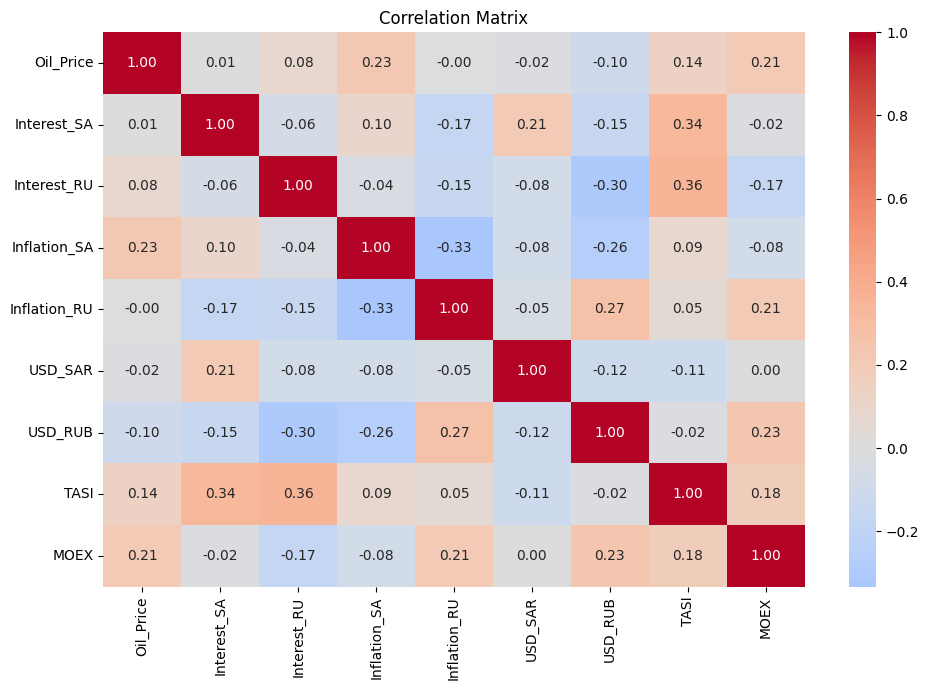

In [8]:
# Correlation Matrix

correlation_matrix = df.drop(columns='Quarter').corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

## 6. Time-Series Visualization

### 6.1 TASI Trend

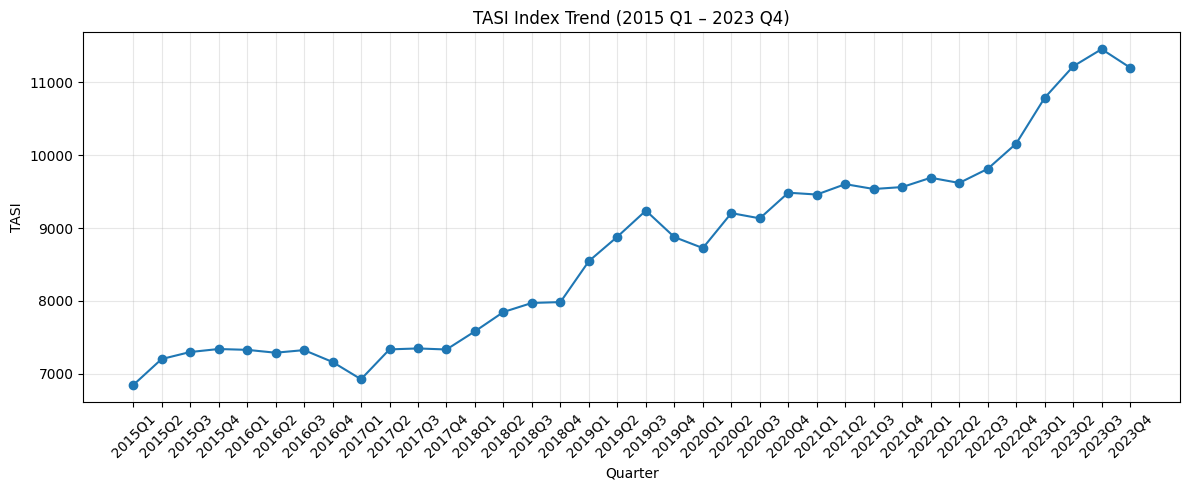

In [9]:
# TASI trend over time

plt.figure(figsize=(12, 5))

plt.plot(
    df['Quarter'].astype(str),
    df['TASI'],
    marker='o'
)

plt.title("TASI Index Trend (2015 Q1 – 2023 Q4)")
plt.xlabel("Quarter")
plt.ylabel("TASI")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 6.2 MOEX Trend

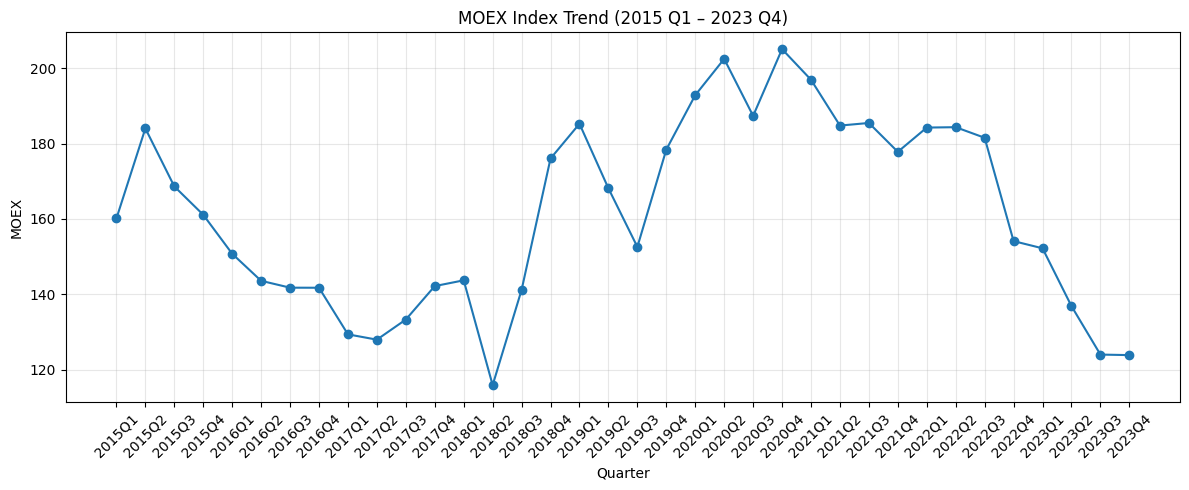

In [10]:
# MOEX trend over time

plt.figure(figsize=(12, 5))

plt.plot(
    df['Quarter'].astype(str),
    df['MOEX'],
    marker='o'
)

plt.title("MOEX Index Trend (2015 Q1 – 2023 Q4)")
plt.xlabel("Quarter")
plt.ylabel("MOEX")
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Oil Price Relationships

### 7.1 Oil Price vs TASI

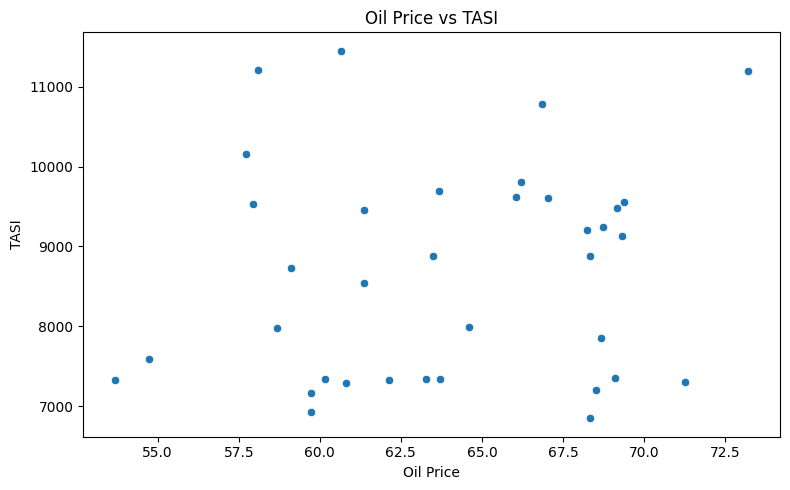

In [11]:
# Oil Price vs TASI

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Oil_Price',
    y='TASI'
)

plt.title("Oil Price vs TASI")
plt.xlabel("Oil Price")
plt.ylabel("TASI")
plt.tight_layout()
plt.show()

### 7.2 Oil Price vs MOEX

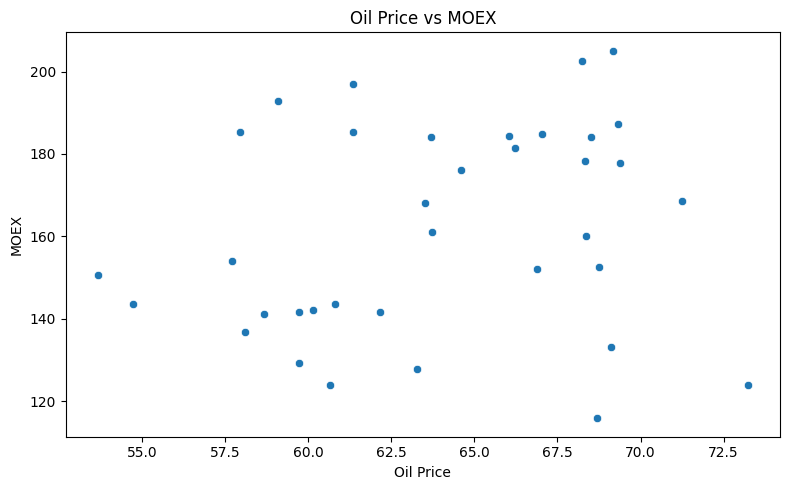

In [12]:
# Oil Price vs MOEX

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='Oil_Price',
    y='MOEX'
)

plt.title("Oil Price vs MOEX")
plt.xlabel("Oil Price")
plt.ylabel("MOEX")
plt.tight_layout()
plt.show()

## 8. Regression Results Summary

In [13]:
# Regression results summary

regression_summary = pd.DataFrame({
    'Model': ['TASI', 'MOEX'],
    'R_squared': [model_tasi.rsquared, model_moex.rsquared],
    'Adjusted_R_squared': [
        model_tasi.rsquared_adj,
        model_moex.rsquared_adj
    ],
    'F_test_p_value': [
        model_tasi.f_pvalue,
        model_moex.f_pvalue
    ],
    'Observations': [
        int(model_tasi.nobs),
        int(model_moex.nobs)
    ]
})

regression_summary

,Model,R_squared,Adjusted_R_squared,F_test_p_value,Observations
0,TASI,0.165109,0.057381,0.217078,36
1,MOEX,0.141469,0.030690,0.300184,36


### 8.1 Coefficients and P-values

In [15]:
# Regression coefficients and p-values

tasi_coefficients = pd.DataFrame({
    'Variable': model_tasi.params.index,
    'Coefficient': model_tasi.params.values,
    'p_value': model_tasi.pvalues.values
})

moex_coefficients = pd.DataFrame({
    'Variable': model_moex.params.index,
    'Coefficient': model_moex.params.values,
    'p_value': model_moex.pvalues.values
})

print("=== TASI Regression Coefficients ===")
display(tasi_coefficients)

print("\n=== MOEX Regression Coefficients ===")
display(moex_coefficients)

=== TASI Regression Coefficients ===


,Variable,Coefficient,p_value
0,const,36427.826125,0.330235
1,Oil_Price,35.903149,0.442881
2,Interest_SA,4444.721986,0.034437
3,Inflation_SA,20.226036,0.979153
4,USD_SAR,-11021.053580,0.277305



=== MOEX Regression Coefficients ===


,Variable,Coefficient,p_value
0,const,92.599287,0.644368
1,Oil_Price,1.204565,0.169629
2,Interest_RU,-15.639953,0.537950
3,Inflation_RU,6.930471,0.412091
4,USD_RUB,0.881357,0.310106


## 9. Multicollinearity Diagnostics

In [16]:
# Multicollinearity check using VIF

from statsmodels.stats.outliers_influence import variance_inflation_factor

# TASI predictors
X_tasi_vif = df[['Oil_Price', 'Interest_SA', 'Inflation_SA', 'USD_SAR']]

vif_tasi = pd.DataFrame({
    'Variable': X_tasi_vif.columns,
    'VIF': [
        variance_inflation_factor(X_tasi_vif.values, i)
        for i in range(X_tasi_vif.shape[1])
    ]
})

print("=== TASI VIF ===")
display(vif_tasi)


# MOEX predictors
X_moex_vif = df[['Oil_Price', 'Interest_RU', 'Inflation_RU', 'USD_RUB']]

vif_moex = pd.DataFrame({
    'Variable': X_moex_vif.columns,
    'VIF': [
        variance_inflation_factor(X_moex_vif.values, i)
        for i in range(X_moex_vif.shape[1])
    ]
})

print("=== MOEX VIF ===")
display(vif_moex)

=== TASI VIF ===


,Variable,VIF
0,Oil_Price,1.054336
1,Interest_SA,1.062655
2,Inflation_SA,1.077125
3,USD_SAR,1.058797


=== MOEX VIF ===


,Variable,VIF
0,Oil_Price,1.014926
1,Interest_RU,1.110334
2,Inflation_RU,1.088167
3,USD_RUB,1.179066


## 10. Export Dataset

In [17]:
# Export the dataset to CSV

df.to_csv("macroeconomic_data.csv", index=False)

print("Dataset exported successfully.")

Dataset exported successfully.


## Key Findings

### TASI Model
- The model explains approximately 16.5% of the variation in TASI (R² = 0.165).
- The overall regression model is not statistically significant at the 5% level (F-test p-value = 0.217).
- The Saudi interest rate is statistically significant at the 5% level (p = 0.034), although the overall model is not statistically significant.
- Oil price, Saudi inflation, and USD/SAR exchange rate are not statistically significant at the 5% level.

### MOEX Model
- The model explains approximately 14.1% of the variation in MOEX (R² = 0.141).
- The overall regression model is not statistically significant at the 5% level (F-test p-value = 0.300).
- None of the predictors are statistically significant at the 5% level.

### Multicollinearity
- VIF values are close to 1 for all predictors in both models.
- This suggests that there is no substantial multicollinearity among the explanatory variables.

## Data Note

The dataset contains 36 quarterly observations covering 2015 Q1 to 2023 Q4.

The original academic project used a combination of publicly sourced and simulated values for selected macroeconomic variables. The dataset is retained in this portfolio project to reproduce and document the analysis.

## Limitations

- The dataset contains only 36 quarterly observations, which limits the statistical power of the regression models.
- Some variables in the original academic dataset were simulated rather than fully sourced from external databases.
- The analysis uses OLS regression and focuses on linear relationships.
- Correlation and regression results should not be interpreted as evidence of causation.
- The relatively high condition numbers reported by the OLS models warrant caution; however, VIF values close to 1 indicate no substantial multicollinearity among the explanatory variables.
- Additional time-series methods and larger datasets could provide more robust analysis.